# Modeling

## Part 0: Importing Libraries

In [65]:
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

import random
import io

In [66]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce RTX 3060


## Part 1: Data Preprocessing

In [67]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [68]:
data_root ="../../Data"
print(os.listdir(data_root))

['test', 'train', 'val']


In [69]:
class RandomJPEGCompression:
    def __init__(self, quality_range=(25, 70), p=0.5):
        self.quality_range = quality_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        buffer = io.BytesIO()
        quality = random.randint(*self.quality_range)
        img.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        return Image.open(buffer).convert("RGB")

In [70]:
train_transform = transforms.Compose([
    transforms.Resize((50, 50)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    RandomJPEGCompression(quality_range=(25, 70), p=0.5),  # compression robustness
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((50, 50)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [71]:
class VideoFrameDataset(Dataset):
    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.image_paths = []
        self.labels = []

        self.classes = ["real", "fake"]
        self.class_to_idx = {
            "real": 0,
            "fake": 1
        }

        valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)

            if not os.path.isdir(class_dir):
                continue

            for video_folder in os.listdir(class_dir):
                video_dir = os.path.join(class_dir, video_folder)

                if not os.path.isdir(video_dir):
                    continue

                for frame_name in os.listdir(video_dir):
                    if frame_name.lower().endswith(valid_extensions):
                        frame_path = os.path.join(video_dir, frame_name)

                        self.image_paths.append(frame_path)
                        self.labels.append(self.class_to_idx[class_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label = self.labels[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [72]:
BATCH_SIZE = 32  
train_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "train"),
    transform=train_transform
)

val_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "val"),
    transform=val_test_transform
)

test_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "test"),
    transform=val_test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [73]:
videos, labels = next(iter(train_loader))
print("Video batch shape:", videos.shape)   # (B, T, C, H, W)
print("Labels shape:", labels.shape)

Video batch shape: torch.Size([32, 3, 50, 50])
Labels shape: torch.Size([32])


## Part 2: Build and Fit the Model

In [74]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CustomCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN, self).__init__()

        # Convolutional Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(3),

            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3)
        )

        # Convolutional Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3)
        )

        # Convolutional Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3)
        )

        # Input image: 50x50x3
        # After 3 maxpool layers:
        # 50 -> 25 -> 12 -> 6
        # Final feature map: 32 x 6 x 6
        self.flatten_size = 32 * 6 * 6

        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flatten_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.fc(x)
        return x

In [75]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomCNN(num_classes=2).to(device)

In [76]:

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [77]:

print(device)

cuda


In [78]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    for videos, labels in tqdm(loader, desc="Training"):
        videos = videos.squeeze().to(device)
        labels = labels.long().to(device)

        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().detach().numpy().ravel())
        all_preds.extend(preds.cpu().detach().numpy().ravel())
        all_probs.extend(probs.cpu().detach().numpy().ravel())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for videos, labels in tqdm(loader, desc="Validation"):
            videos = videos.squeeze().to(device)
            labels = labels.long().to(device)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().detach().numpy().ravel())
            all_preds.extend(preds.cpu().detach().numpy().ravel())
            all_probs.extend(probs.cpu().detach().numpy().ravel())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)
    epoch_auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, epoch_acc, epoch_f1, epoch_auc


In [79]:
import wandb

In [80]:
wandb.login(key= "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")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\fatah.rahimi\_netrc


True

In [81]:
wandb.init(project = "model_12.1",id="silvery-grass-12.1",resume="allow")

In [82]:
wandb.watch(model)

In [84]:
checkpoint_path = "video_checkpoint_12.1.pth"
model_path = "video_model_12.1.pth"

epochs = 50
patience = 10
counter = 0
best_val_f1 = 0.0
start_epoch = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_f1s, val_f1s = [], []
val_aucs = []


# =========================================================
# Load checkpoint safely
# =========================================================
if os.path.exists(checkpoint_path):

    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Load model weights
    model.load_state_dict(checkpoint["model_state_dict"])

    # Load optimizer safely
    try:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        print("Optimizer restored successfully")

    except ValueError:
        print("Optimizer structure changed -> using fresh optimizer")

    # Restore training state
    start_epoch = checkpoint["epoch"] + 1
    best_val_f1 = checkpoint.get("best_val_f1", 0.0)
    counter = checkpoint.get("counter", 0)

    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])

    train_accuracies = checkpoint.get("train_accuracies", [])
    val_accuracies = checkpoint.get("val_accuracies", [])

    train_f1s = checkpoint.get("train_f1s", [])
    val_f1s = checkpoint.get("val_f1s", [])

    val_aucs = checkpoint.get("val_aucs", [])

    print(f"Resuming from epoch {start_epoch}")

# =========================================================
# Training Loop
# =========================================================
for epoch in range(start_epoch, epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")
        

    # =====================================================
    # Train
    # =====================================================
    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # =====================================================
    # Validation
    # =====================================================
    val_loss, val_acc, val_f1, val_auc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )
    
    # =====================================================
    # Save Metrics
    # =====================================================
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    val_aucs.append(val_auc)

    # =====================================================
    # Print Results
    # =====================================================
    print(
        f"Train Loss={train_loss:.4f}, "
        f"Train Acc={train_acc:.4f}, "
        f"Train F1={train_f1:.4f} | "
        f"Val Loss={val_loss:.4f}, "
        f"Val Acc={val_acc:.4f}, "
        f"Val F1={val_f1:.4f}, "
        f"Val AUC={val_auc:.4f}"
    )

    torch.save(model.state_dict(), model_path)
    # =====================================================
    # Save Checkpoint
    # =====================================================
    torch.save({

        "epoch": epoch,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "best_val_f1": best_val_f1,

        "counter": counter,

        "train_losses": train_losses,
        "val_losses": val_losses,

        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,

        "train_f1s": train_f1s,
        "val_f1s": val_f1s,

        "val_aucs": val_aucs

    }, checkpoint_path)

    # =====================================================
    # WandB Logging
    # =====================================================
    wandb.log({

    "Accuracy/Train": train_acc,
    "Accuracy/Validation": val_acc,

    "Loss/Train": train_loss,
    "Loss/Validation": val_loss,

    "F1/Train": train_f1,
    "F1/Validation": val_f1,

    "AUC/Validation": val_auc

}, step=epoch)
    # =====================================================
    # Early Stopping
    # =====================================================
    if counter >= patience:

        print("⛔ Early stopping triggered")
        break

# =========================================================
# Finish WandB
# =========================================================
wandb.finish()


Epoch 1/50


Validation: 100%|██████████| 387/387 [00:23<00:00, 16.23it/s]


Train Loss=0.5337, Train Acc=0.7305, Train F1=0.7431 | Val Loss=0.4491, Val Acc=0.7895, Val F1=0.7859, Val AUC=0.8834

Epoch 2/50


Validation: 100%|██████████| 387/387 [00:12<00:00, 30.03it/s]


Train Loss=0.4415, Train Acc=0.7954, Train F1=0.8057 | Val Loss=0.4457, Val Acc=0.7937, Val F1=0.7989, Val AUC=0.8944

Epoch 3/50


...

Validation: 100%|██████████| 387/387 [00:16<00:00, 24.19it/s]


Train Loss=0.1740, Train Acc=0.9267, Train F1=0.9302 | Val Loss=0.2589, Val Acc=0.9020, Val F1=0.8884, Val AUC=0.9680

Epoch 50/50


Validation: 100%|██████████| 387/387 [00:14<00:00, 27.51it/s]


Train Loss=0.1750, Train Acc=0.9239, Train F1=0.9275 | Val Loss=0.2813, Val Acc=0.9060, Val F1=0.8931, Val AUC=0.9674


AUC/Validation,▁▂▂▂▃▄▄▄▄▅▅▅▅▆▇▆▇▇▆▇▇▇▇▇▇▇▇█████▇█▇█████
Accuracy/Train,▁▃▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
Accuracy/Validation,▁▁▂▂▃▃▂▃▃▄▄▅▆▆▅▆▆▆▆▇▇▇▇▇▇▇█▇▇█▇▇▇▇▇▇████
F1/Train,▁▃▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
F1/Validation,▁▂▂▁▂▃▃▃▃▄▄▄▅▆▆▆▆▆▆▇▇▆▆▇▇▇▇▇▇█▇▇▇▇▇▇█▇██
Loss/Train,█▆▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
Loss/Validation,██▇▇▆▆▆▆▆▆▅▅▅▄▄▃▃▃▃▄▃▃▃▃▃▂▃▂▁▁▂▂▂▃▃▂▁▂▂▂
AUC/Validation,0.96744
Accuracy/Train,0.9239
Accuracy/Validation,0.90601
F1/Train,0.92754


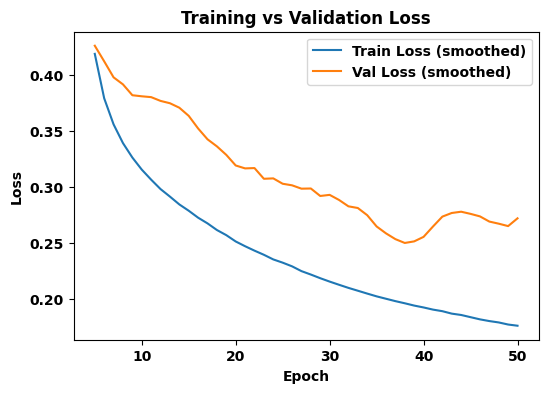

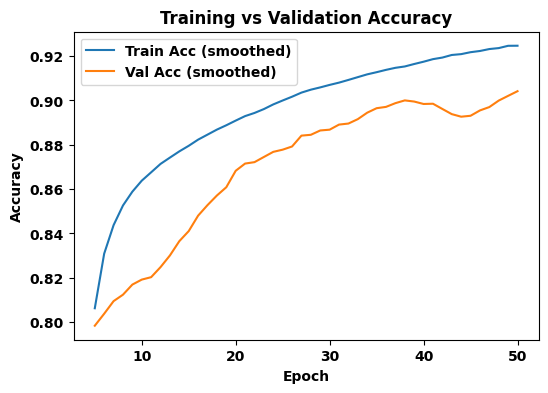

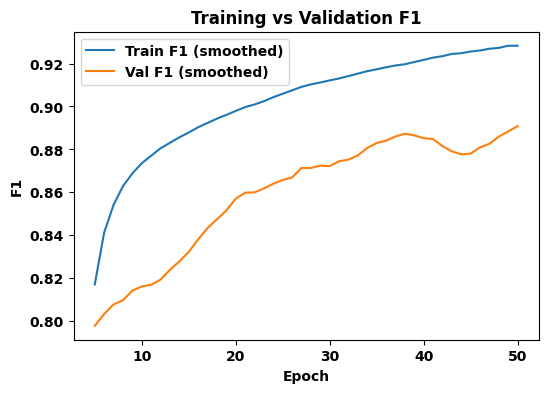

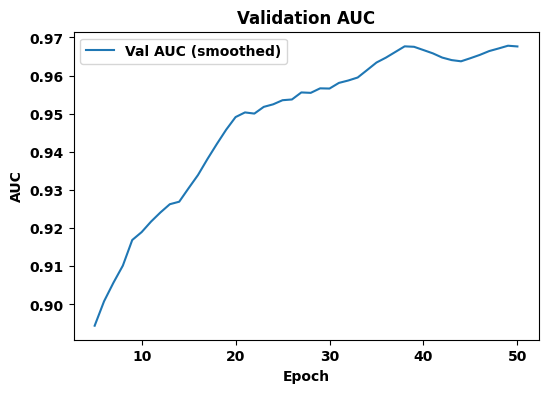

In [85]:
# Set global bold style for most text elements
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.handlelength'] = 2

def bold_tick_labels():
    """Make tick labels bold for the current figure"""
    ax = plt.gca()
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

def moving_avg(data, window=5):
    return np.convolve(data, np.ones(window)/window, mode='valid')

epochs_range = range(1, len(train_losses) + 1)

window = 5   # adjust as needed (try 3, 5, 7)

# ----- Figure 1: Loss -----
plt.figure(figsize=(6,4))
# Raw (semi-transparent)
# plt.plot(epochs_range, train_losses, alpha=0.3, label='Train Loss (raw)')
# plt.plot(epochs_range, val_losses, alpha=0.3, label='Val Loss (raw)')
# Smoothed
smoothed_train = moving_avg(train_losses, window)
smoothed_val   = moving_avg(val_losses, window)
trimmed_epochs = epochs_range[window-1:]   # same length as smoothed arrays
plt.plot(trimmed_epochs, smoothed_train, label='Train Loss (smoothed)')
plt.plot(trimmed_epochs, smoothed_val,   label='Val Loss (smoothed)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
bold_tick_labels()
plt.show()

# ----- Figure 2: Accuracy -----
plt.figure(figsize=(6,4))
# plt.plot(epochs_range, train_accuracies, alpha=0.3, label='Train Acc (raw)')
# plt.plot(epochs_range, val_accuracies, alpha=0.3, label='Val Acc (raw)')
smoothed_train = moving_avg(train_accuracies, window)
smoothed_val   = moving_avg(val_accuracies, window)
plt.plot(trimmed_epochs, smoothed_train, label='Train Acc (smoothed)')
plt.plot(trimmed_epochs, smoothed_val,   label='Val Acc (smoothed)')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
bold_tick_labels()
plt.show()

# ----- Figure 3: F1 Score -----
plt.figure(figsize=(6,4))
# plt.plot(epochs_range, train_f1s, alpha=0.3, label='Train F1 (raw)')
# plt.plot(epochs_range, val_f1s, alpha=0.3, label='Val F1 (raw)')
smoothed_train = moving_avg(train_f1s, window)
smoothed_val   = moving_avg(val_f1s, window)
plt.plot(trimmed_epochs, smoothed_train, label='Train F1 (smoothed)')
plt.plot(trimmed_epochs, smoothed_val,   label='Val F1 (smoothed)')
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Training vs Validation F1")
plt.legend()
bold_tick_labels()
plt.show()

# ----- Figure 4: Validation AUC (single curve) -----
plt.figure(figsize=(6,4))
# plt.plot(epochs_range, val_aucs, alpha=0.3, label='Val AUC (raw)')
smoothed_auc = moving_avg(val_aucs, window)
plt.plot(trimmed_epochs, smoothed_auc, label='Val AUC (smoothed)')
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC")
plt.legend()
bold_tick_labels()
plt.show()

## Part 3: Evaluate the Model

In [86]:
#best_model_path = "/content/drive/MyDrive/XST-Deepfake-Detection/new_version/video_best_model.pth"

In [87]:
model.load_state_dict(torch.load(model_path, map_location=device))

C:\Users\fatah.rahimi\AppData\Local\Temp\ipykernel_22548\1340442549.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loca

<All keys matched successfully>

In [88]:
def test_model(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for videos, labels in tqdm(loader, desc="Testing"):
            videos = videos.to(device)
            labels = labels.long().to(device)

            outputs = model(videos)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().detach().numpy().ravel())
            all_preds.extend(preds.cpu().detach().numpy().ravel())
            all_probs.extend(probs.cpu().detach().numpy().ravel())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1-score: {f1:.4f}")
    print(f"Test AUC: {auc:.4f}")

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


In [89]:
all_labels, all_preds, all_probs = test_model(model, test_loader, device)

Testing: 100%|██████████| 401/401 [00:22<00:00, 18.04it/s]

Test Accuracy: 0.8538
Test F1-score: 0.8403
Test AUC: 0.9116


              precision    recall  f1-score   support

        fake       0.86      0.87      0.87      6928
        real       0.84      0.84      0.84      5877

    accuracy                           0.85     12805
   macro avg       0.85      0.85      0.85     12805
weighted avg       0.85      0.85      0.85     12805

Confusion Matrix:
 [[6008  920]
 [ 952 4925]]


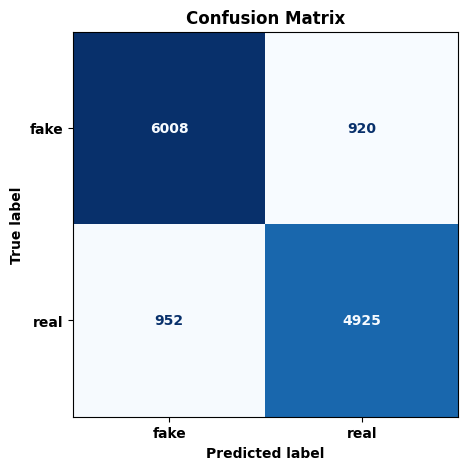

In [90]:
target_names = ["fake", "real"]

print(classification_report(
    all_labels.astype(int),
    all_preds.astype(int),
    target_names=target_names
))

cm = confusion_matrix(all_labels.astype(int), all_preds.astype(int))
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Blues", colorbar=False, ax=ax)
plt.title("Confusion Matrix")
plt.show()

In [91]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
THRESHOLD = 0.5                             # decision threshold (for score distribution)
CLASS_NAMES = ["fake", "real"]  

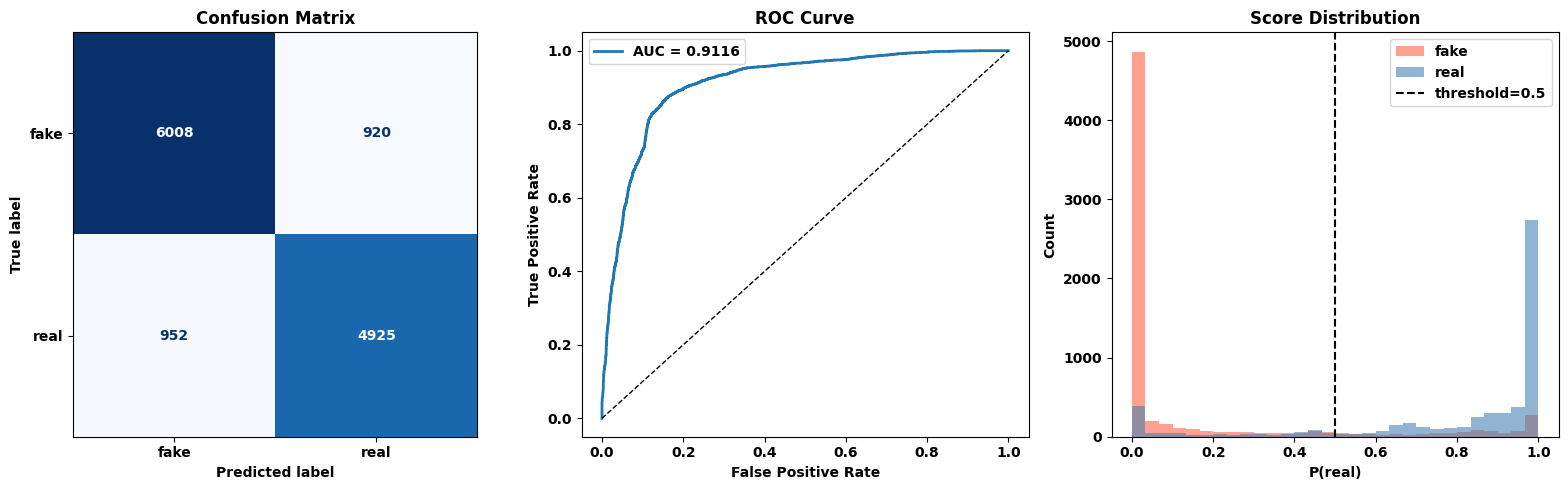

Plots saved to prediction_plots.png


In [92]:
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# Check if any labels exist
has_labels = len(all_labels) > 0
if has_labels:
    auc_score = roc_auc_score(all_labels, all_probs)
else:
    auc_score = 0.0

# ---------- 3. PLOT THE THREE FIGURES ----------
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

if not has_labels:
    print("No ground-truth labels — skipping plots.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    ).plot(cmap="Blues", colorbar=False, ax=axes[0])
    axes[0].set_title("Confusion Matrix", fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    axes[1].plot(fpr, tpr, label=f"AUC = {auc_score:.4f}", linewidth=2)
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[1].set_xlabel("False Positive Rate", fontweight='bold')
    axes[1].set_ylabel("True Positive Rate", fontweight='bold')
    axes[1].set_title("ROC Curve", fontweight='bold')
    axes[1].legend()

    # Score Distribution
    fake_probs = all_probs[all_labels == 0]
    real_probs = all_probs[all_labels == 1]
    axes[2].hist(fake_probs, bins=30, alpha=0.6, label="fake", color="tomato")
    axes[2].hist(real_probs, bins=30, alpha=0.6, label="real", color="steelblue")
    axes[2].axvline(THRESHOLD, color="black", linestyle="--", linewidth=1.5, label=f"threshold={THRESHOLD}")
    axes[2].set_xlabel("P(real)", fontweight='bold')
    axes[2].set_ylabel("Count", fontweight='bold')
    axes[2].set_title("Score Distribution", fontweight='bold')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig("prediction_plots.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plots saved to prediction_plots.png")

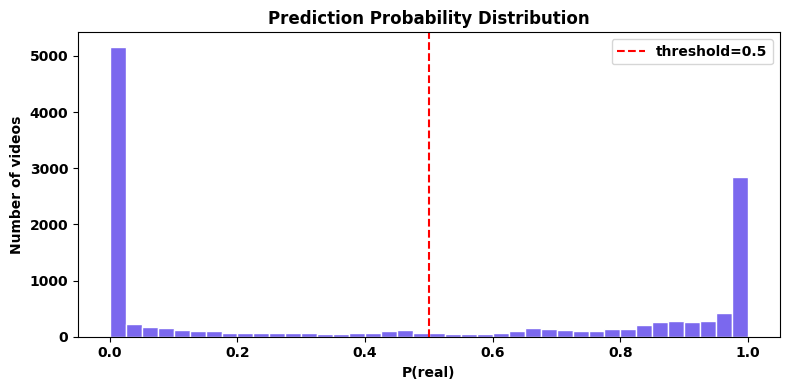

In [93]:
plt.figure(figsize=(8, 4))
plt.hist(all_probs, bins=40, color="mediumslateblue", edgecolor="white")
plt.axvline(THRESHOLD, color="red", linestyle="--", linewidth=1.5, label=f"threshold={THRESHOLD}")
plt.xlabel("P(real)")
plt.ylabel("Number of videos")
plt.title("Prediction Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()

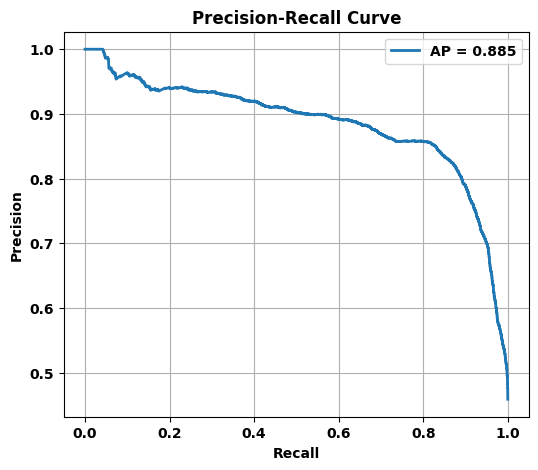

In [94]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(all_labels, all_probs)
ap_score = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, linewidth=2, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

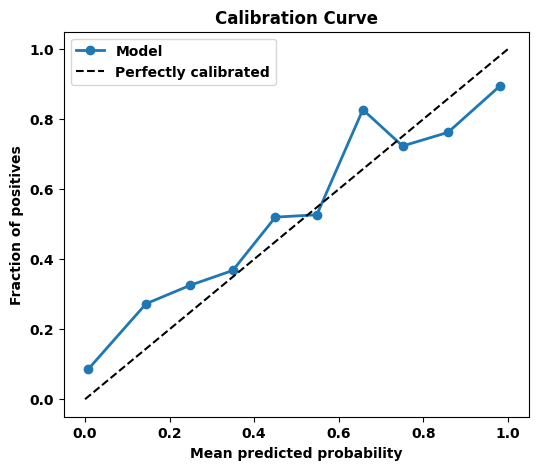

In [95]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(all_labels, all_probs, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
plt.plot([0,1], [0,1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()

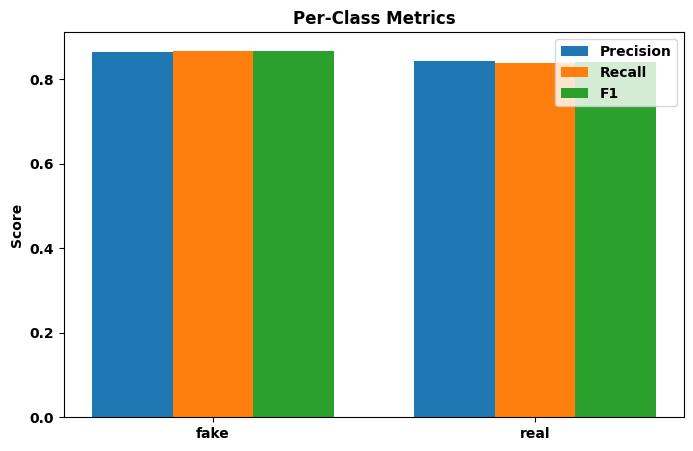

In [96]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import pandas as pd

precision = precision_score(all_labels, all_preds, average=None)
recall = recall_score(all_labels, all_preds, average=None)
f1 = f1_score(all_labels, all_preds, average=None)

x = np.arange(len(CLASS_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width, precision, width, label='Precision')
ax.bar(x, recall, width, label='Recall')
ax.bar(x + width, f1, width, label='F1')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Score')
ax.set_title('Per‑Class Metrics')
ax.legend()
plt.show()

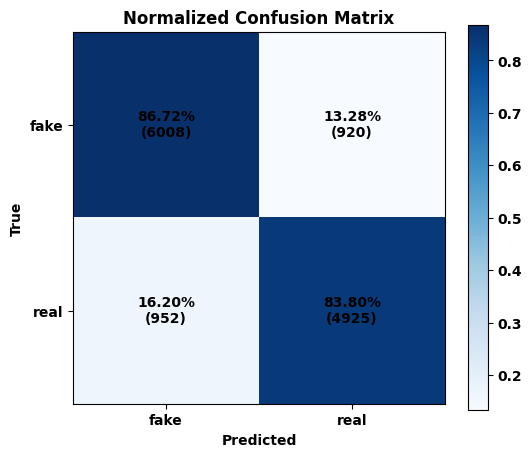

In [97]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm_norm, cmap='Blues')
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_norm[i,j]:.2%}\n({cm[i,j]})', 
                ha='center', va='center')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.colorbar(im)
plt.show()

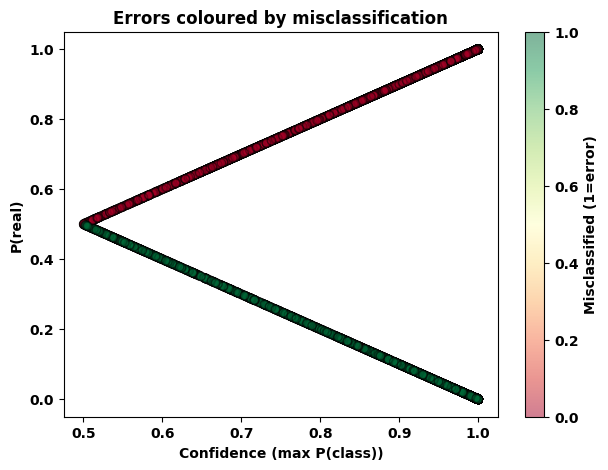

In [98]:
errors = (all_preds != all_labels).astype(int)
confidences = np.maximum(all_probs, 1 - all_probs)  # max probability

plt.figure(figsize=(7,5))
plt.scatter(confidences, all_probs, c=errors, cmap='RdYlGn', alpha=0.5, edgecolors='k')
plt.xlabel('Confidence (max P(class))')
plt.ylabel('P(real)')
plt.title('Errors coloured by misclassification')
plt.colorbar(label='Misclassified (1=error)')
plt.show()

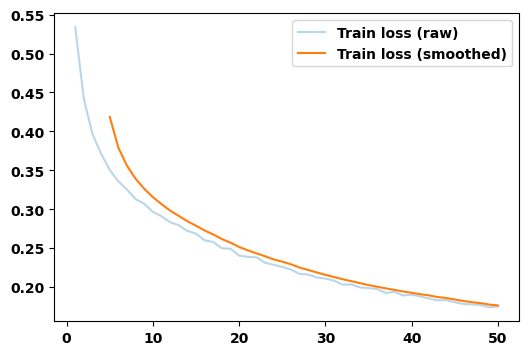

In [99]:
def moving_avg(data, window=5):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_losses, alpha=0.3, label='Train loss (raw)')
plt.plot(epochs_range[len(epochs_range)-len(moving_avg(train_losses)):], 
         moving_avg(train_losses), label='Train loss (smoothed)')
# same for val_losses
plt.legend()
plt.show()

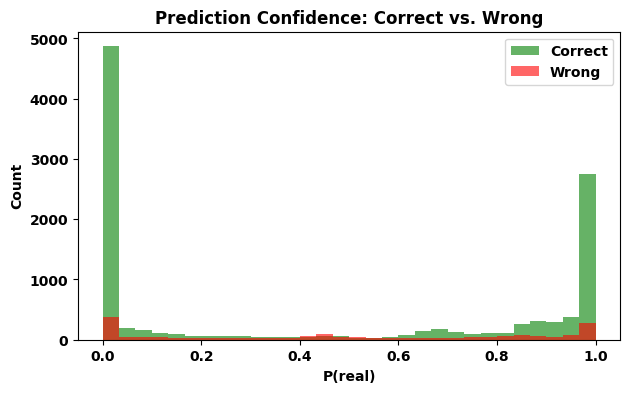

In [100]:
correct_probs = all_probs[all_preds == all_labels]
wrong_probs = all_probs[all_preds != all_labels]

plt.figure(figsize=(7,4))
plt.hist(correct_probs, bins=30, alpha=0.6, label='Correct', color='green')
plt.hist(wrong_probs, bins=30, alpha=0.6, label='Wrong', color='red')
plt.xlabel('P(real)')
plt.ylabel('Count')
plt.title('Prediction Confidence: Correct vs. Wrong')
plt.legend()
plt.show()

In [101]:
from sklearn.utils import resample

n_bootstraps = 1000
bootstrapped_aucs = []
rng = np.random.RandomState(42)
for _ in range(n_bootstraps):
    indices = rng.randint(0, len(all_labels), len(all_labels))
    if len(np.unique(all_labels[indices])) < 2:
        continue
    boot_auc = roc_auc_score(all_labels[indices], all_probs[indices])
    bootstrapped_aucs.append(boot_auc)

lower = np.percentile(bootstrapped_aucs, 2.5)
upper = np.percentile(bootstrapped_aucs, 97.5)
print(f'AUC = {auc_score:.3f} (95% CI: {lower:.3f}–{upper:.3f})')

AUC = 0.912 (95% CI: 0.906–0.917)


In [ ]:
from torchinfo import summary
summary(model, input_size=(32, 3, 224, 224), device=device)

In [102]:

total_params = 0
trainable_params = 0
non_trainable_params = 0

for name, parameter in model.named_parameters():
    param_count = parameter.numel()
    total_params += param_count
    if parameter.requires_grad:
        trainable_params += param_count
    else:
        non_trainable_params += param_count

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")

Total parameters: 657,596
Trainable parameters: 657,596
Non-trainable parameters: 0
